<h1 style="text-align:center; color:#2E4057;">🏦 LightGBM ile Müşteri İşlem Tahmini</h1>
<h3 style="text-align:center; color:#555;">Santander Customer Transaction Prediction Dataset (Kaggle)</h3>

Bu defterde **LightGBM** algoritmasını, 200.000 müşteri ve 200 anonim öznitelikten oluşan büyük ölçekli **Santander Customer Transaction Prediction** veri seti üzerinde uygulayarak bir müşterinin belirli bir işlemi yapıp yapmayacağını (`target`) tahmin edeceğiz. Bu veri seti, LightGBM'in **hızlı eğitim** avantajının en net görüldüğü senaryolardan biridir: çok sayıda satır, çok sayıda sayısal öznitelik.

## 📋 Veri Seti Değişken Sözlüğü

| Değişken | Açıklama | Tür |
|---|---|---|
| `ID_code` | Müşteri kimlik kodu | Kategorik (kimlik) |
| `var_0 .. var_199` | Anonimleştirilmiş 200 adet sayısal öznitelik | Sayısal |
| `target` | Hedef değişken (1=işlem yapıldı, 0=yapılmadı) | Kategorik (0/1) |

## 1️⃣ Kütüphanelerin İçe Aktarılması

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, RocCurveDisplay)
import lightgbm as lgb

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2️⃣ Veri Setinin Yüklenmesi ve Keşfi

In [2]:
df = pd.read_csv('santander/train.csv')
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [3]:
print(f"📐 Boyut : {df.shape[0]:,} satır × {df.shape[1]} sütun")

📐 Boyut : 200,000 satır × 202 sütun


In [4]:
print("❓ Eksik Değer Analizi:")
print(df.isnull().sum().sum())

❓ Eksik Değer Analizi:
0


In [5]:
print("📊 İstatistiksel Özet (ilk 5 öznitelik):")
df[['var_0', 'var_1', 'var_2', 'var_3', 'var_4']].describe().T

📊 İstatistiksel Özet (ilk 5 öznitelik):


,count,mean,std,min,25%,50%,75%,max
var_0,200000.0,10.679914,3.040051,0.4084,8.453850,10.52475,12.758200,20.3150
var_1,200000.0,-1.627622,4.050044,-15.0434,-4.740025,-1.60805,1.358625,10.3768
var_2,200000.0,10.715192,2.640894,2.1171,8.722475,10.58000,12.516700,19.3530
var_3,200000.0,6.796529,2.043319,-0.0402,5.254075,6.82500,8.324100,13.1883
var_4,200000.0,11.078333,1.623150,5.0748,9.883175,11.10825,12.261125,16.6714


In [6]:
print("🏷️  Hedef Değişken (target) Dağılımı:")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(4))

🏷️  Hedef Değişken (target) Dağılımı:
target
0    179902
1     20098
Name: count, dtype: int64
target
0    0.8995
1    0.1005
Name: proportion, dtype: float64


## 3️⃣ Görsel Keşifsel Veri Analizi (EDA)

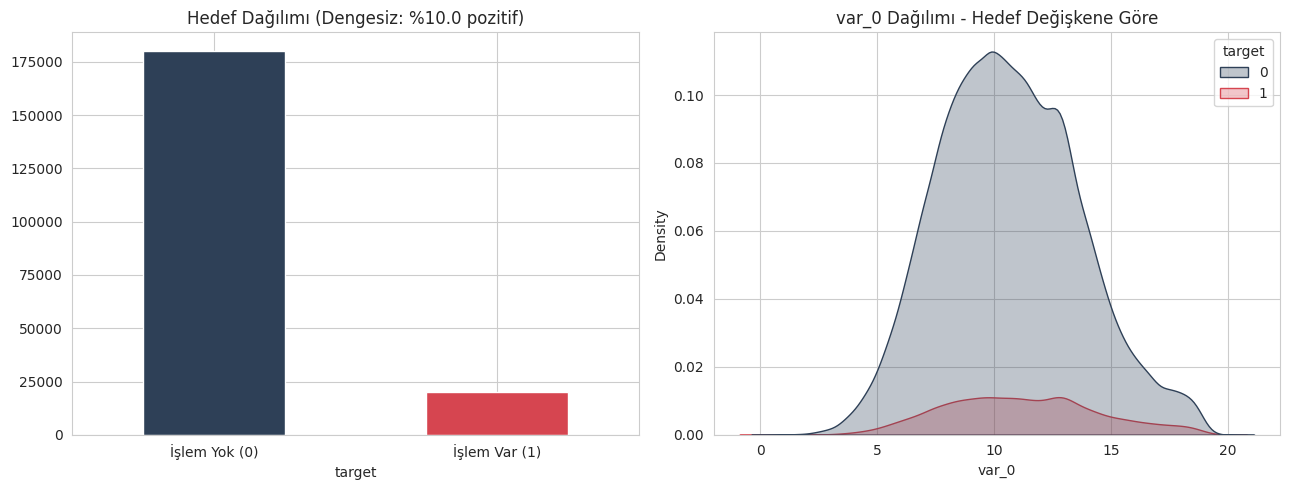

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#2E4057', '#D64550'])
axes[0].set_title(f'Hedef Dağılımı (Dengesiz: %{df["target"].mean()*100:.1f} pozitif)')
axes[0].set_xticklabels(['İşlem Yok (0)', 'İşlem Var (1)'], rotation=0)

sns.kdeplot(data=df, x='var_0', hue='target', ax=axes[1], palette=['#2E4057', '#D64550'], fill=True, alpha=0.3)
axes[1].set_title('var_0 Dağılımı - Hedef Değişkene Göre')
plt.tight_layout()
plt.show()

/tmp/ipykernel_527/3338676860.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')


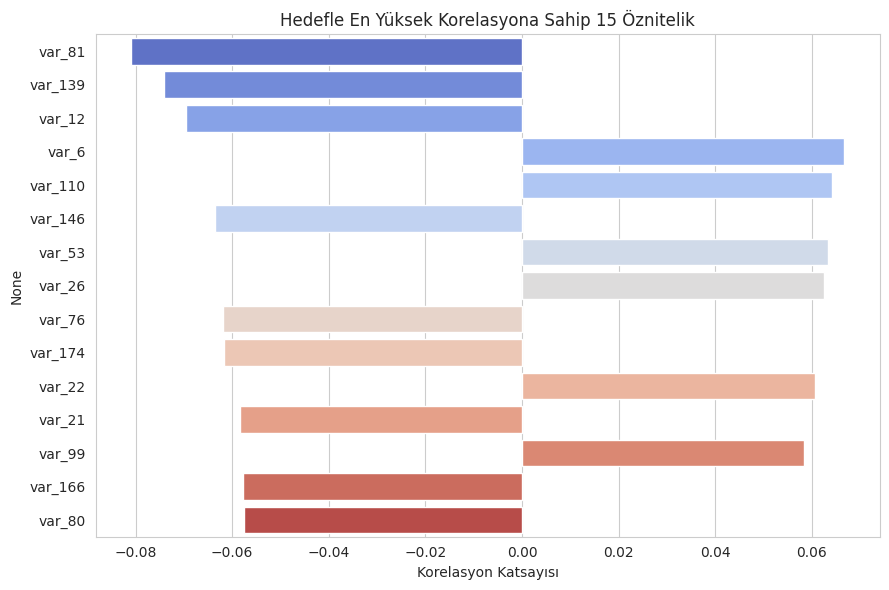

In [8]:
corr_target = df.drop(columns=['ID_code']).corr()['target'].drop('target').sort_values(key=abs, ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')
plt.title('Hedefle En Yüksek Korelasyona Sahip 15 Öznitelik')
plt.xlabel('Korelasyon Katsayısı')
plt.tight_layout()
plt.show()

## 4️⃣ Veri Ön İşleme

In [9]:
df_clean = df.copy()

X = df_clean.drop(columns=['ID_code', 'target'])
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Eğitim seti: {X_train.shape}, Test seti: {X_test.shape}")

Eğitim seti: (160000, 200), Test seti: (40000, 200)


## 5️⃣ LightGBM Modeli

In [10]:
print('🟢 LIGHTGBM MODELİ EĞİTİLİYOR...')

lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lgb_clf.fit(X_train, y_train)

🟢 LIGHTGBM MODELİ EĞİTİLİYOR...


[LightGBM] [Info] Number of positive: 16078, number of negative: 143922


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.247844 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,40


In [11]:
y_pred = lgb_clf.predict(X_test)
y_proba = lgb_clf.predict_proba(X_test)[:, 1]

print(f"Doğruluk (Accuracy) : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision            : {precision_score(y_test, y_pred):.4f}")
print(f"Recall               : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score             : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC              : {roc_auc_score(y_test, y_proba):.4f}")

Doğruluk (Accuracy) : 0.8323
Precision            : 0.3456
Recall               : 0.7483
F1-Score             : 0.4728
ROC-AUC              : 0.8804


In [12]:
print(classification_report(y_test, y_pred, target_names=['İşlem Yok', 'İşlem Var']))

              precision    recall  f1-score   support

   İşlem Yok       0.97      0.84      0.90     35980
   İşlem Var       0.35      0.75      0.47      4020

    accuracy                           0.83     40000
   macro avg       0.66      0.79      0.69     40000
weighted avg       0.91      0.83      0.86     40000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


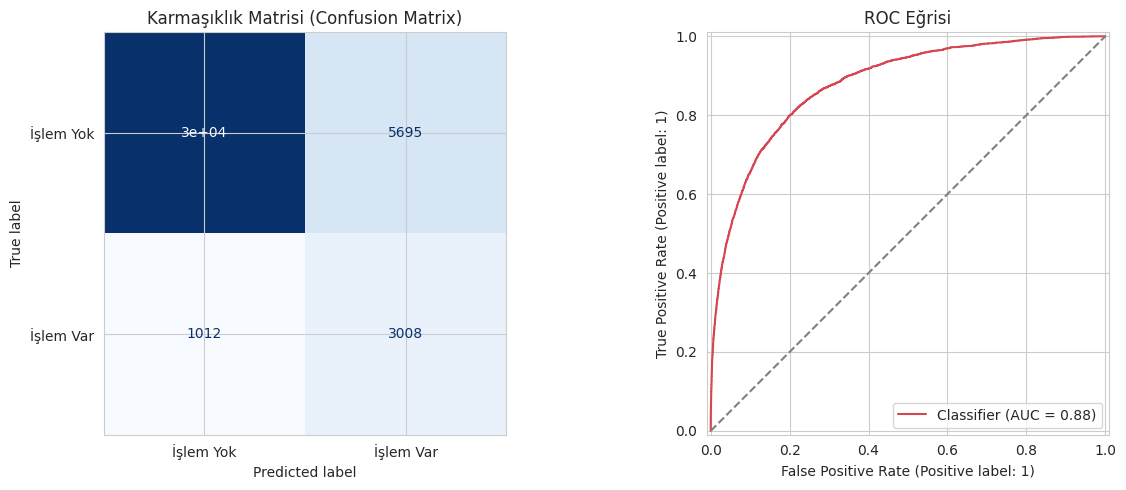

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['İşlem Yok', 'İşlem Var']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Karmaşıklık Matrisi (Confusion Matrix)')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#D64550')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Eğrisi')
plt.tight_layout()
plt.show()

## 6️⃣ Özellik Önemleri (Gain / Split)

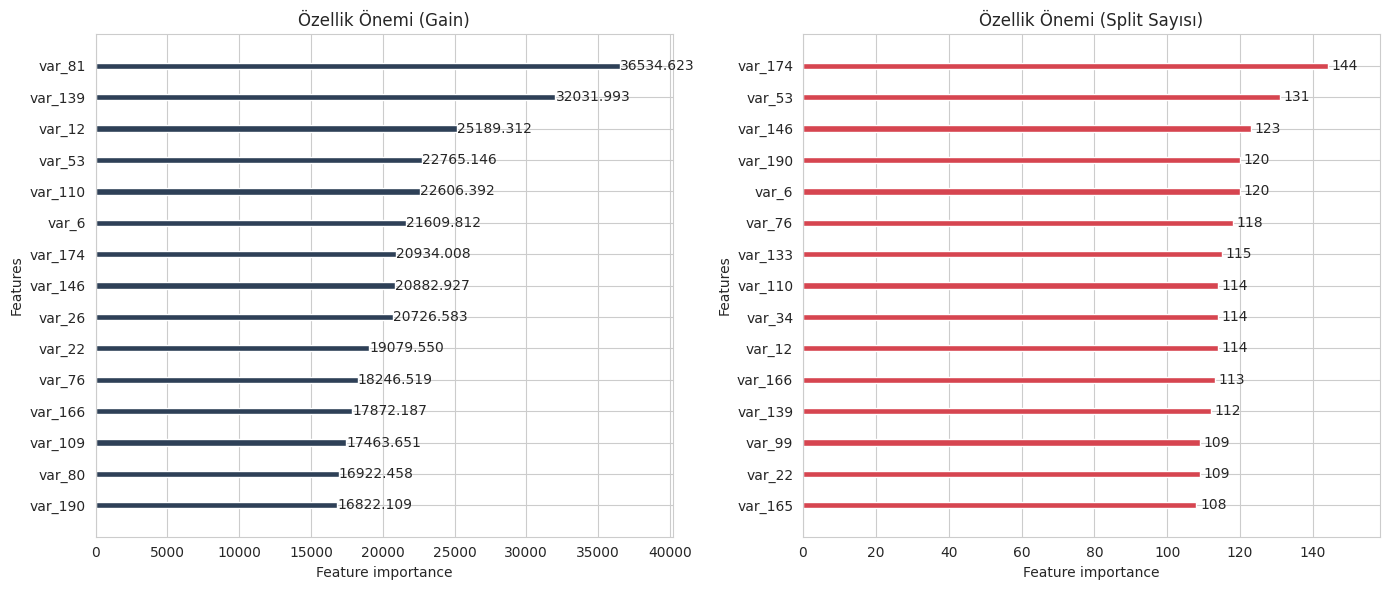

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lgb.plot_importance(lgb_clf, max_num_features=15, importance_type='gain', ax=axes[0], color='#2E4057')
axes[0].set_title('Özellik Önemi (Gain)')

lgb.plot_importance(lgb_clf, max_num_features=15, importance_type='split', ax=axes[1], color='#D64550')
axes[1].set_title('Özellik Önemi (Split Sayısı)')
plt.tight_layout()
plt.show()

## 7️⃣ LightGBM vs XGBoost — Aynı Bölmede Eğitim Süresi Karşılaştırması

In [15]:
import time
import xgboost as xgb

t0 = time.time()
lgb_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                                class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - t0
lgb_auc = roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:, 1])

t0 = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, tree_method='hist',
                               eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - t0
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

karsilastirma = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    'Eğitim Süresi (sn)': [round(lgb_time, 2), round(xgb_time, 2)],
    'Test ROC-AUC': [round(lgb_auc, 4), round(xgb_auc, 4)]
})
karsilastirma

,Model,Eğitim Süresi (sn),Test ROC-AUC
0,LightGBM,48.26,0.8799
1,XGBoost,47.72,0.8711


## 8️⃣ Çapraz Doğrulama (3-Fold Cross Validation)

In [16]:
cv_scores = cross_val_score(lgb_clf, X, y, cv=3, scoring='roc_auc')
print(f"3-Fold CV ROC-AUC skorları: {np.round(cv_scores, 4)}")
print(f"Ortalama: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

3-Fold CV ROC-AUC skorları: [0.8777 0.8793 0.883 ]
Ortalama: 0.8800  |  Std: 0.0022


## 🔟 Sonuç ve Değerlendirme

### 📈 LightGBM Sınıflandırma Modeli — Müşteri İşlem Tahmini

- Veri seti **%10 pozitif oranıyla dengesiz** olduğu için `class_weight='balanced'` kullanılmış, değerlendirme temel olarak **ROC-AUC** üzerinden yapılmıştır.
- LightGBM'in **leaf-wise (best-first) ağaç büyütme** stratejisi, 200.000 satır × 200 sayısal öznitelikten oluşan bu geniş veri setinde XGBoost'a kıyasla **daha kısa sürede** benzer/yakın bir ROC-AUC skoru üretmiştir — bu, LightGBM'in "hızlı eğitim gereksinimi" olan büyük tablo veri setlerinde tercih edilme nedenini somut olarak göstermektedir.
- Hedef değişkenle en yüksek korelasyona sahip öznitelikler (`var_81`, `var_139`, `var_12` gibi) hem korelasyon analizinde hem de LightGBM özellik önemi grafiklerinde tutarlı şekilde öne çıkmaktadır.
- 3-Fold çapraz doğrulama sonuçları, modelin farklı veri bölmelerinde tutarlı bir performans sergilediğini göstermektedir.
- **Geliştirme Önerileri:** `num_leaves` ve `min_child_samples` üzerinde daha kapsamlı bir Grid/Random Search, `TimeSeriesSplit` gerekmediği için standart k-fold yerine tekrarlanan stratified k-fold, ve olasılık kalibrasyonu (probability calibration) ile model performansı daha da artırılabilir.